In [1]:
!pip install -q streamlit shap matplotlib seaborn scipy joblib scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# MediTrack — Readmission Risk Prediction
## Model 1: Logistic Regression Baseline & Coefficient Analysis
This notebook builds a complete, self-contained **Logistic Regression** baseline model on the canonical UCI Diabetes 130-US Hospitals dataset (99,343 encounters). It features standardized feature scaling, class weighting, clinical threshold tuning, ROC/PR curve plots, confusion matrix heatmaps, and odds-ratio coefficient explainability.


In [2]:
# Step 1 — Environment Setup & Library Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score,
    recall_score, f1_score, accuracy_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else None


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score,
    recall_score, f1_score, accuracy_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    pass

# Import shared preprocessing for canonical split & feature consistency
import sys
sys.path.insert(0, '.')
from shared_preprocessing import (
    get_classical_split, prepare_classical_features,
    apply_feature_engineering, group_diagnosis,
    FEATURES, OHE_COLUMNS, MEDICATION_COLS
)

# Step 2 — Load Raw Dataset & Apply Deceased/Hospice Exclusion Rules
data_path = 'diabetic_data.csv'
if not os.path.exists(data_path):
    data_path = '../diabetic_data.csv'

# FIXED: removed on_bad_lines='skip' which was dropping ~24,000 valid rows
df_raw = pd.read_csv(data_path)
print('Raw dataset shape:', df_raw.shape)

# Standardize missing values ('?' -> NaN)
df_clean = df_raw.replace('?', np.nan).copy()

# Exclude deceased and hospice discharges (IDs: 11, 13, 14, 19, 20, 21)
exclude_disposition = [11, 13, 14, 19, 20, 21]
df_clean = df_clean[~df_clean['discharge_disposition_id'].isin(exclude_disposition)].copy()
print('Encounters after deceased/hospice exclusion:', len(df_clean))

# Construct binary target (<30 days readmission)
df_clean['risk_target'] = (df_clean['readmitted'] == '<30').astype(int)
pos_cnt = df_clean['risk_target'].sum()
print(f'Target Distribution: Readmitted <30d = {pos_cnt} ({pos_cnt/len(df_clean):.2%}), Not Readmitted = {len(df_clean)-pos_cnt}')

Raw dataset shape: (101766, 50)


Encounters after deceased/hospice exclusion: 99343
Target Distribution: Readmitted <30d = 11314 (11.39%), Not Readmitted = 88029


In [4]:

icd9_official_descriptions = {
    '428': 'congestive heart failure left ventricular failure cardiac insufficiency',
    '414': 'coronary atherosclerosis chronic ischemic heart disease coronary artery disease',
    '786': 'symptoms involving respiratory system chest pain dyspnea shortness of breath',
    '410': 'acute myocardial infarction heart attack coronary thrombosis',
    '486': 'pneumonia organism unspecified lower respiratory tract infection',
    '427': 'cardiac dysrhythmias atrial fibrillation flutter heart rhythm disorder',
    '491': 'chronic bronchitis chronic obstructive pulmonary disease copd',
    '715': 'osteoarthrosis osteoarthritis degenerative joint disease',
    '682': 'other cellulitis and abscess acute skin infection',
    '434': 'occlusion of cerebral arteries acute ischemic stroke cerebrovascular accident',
    '276': 'disorders of fluid electrolyte and acid base balance dehydration hyponatremia',
    '250': 'diabetes mellitus with vascular manifestations uncontrolled blood glucose hyperosmolality',
    '401': 'essential primary hypertension high blood pressure',
    '496': 'chronic airway obstruction not elsewhere classified copd lung disease',
    '599': 'urinary tract infection kidney urethra bladder inflammation',
    '403': 'hypertensive chronic kidney disease renal disease',
    '411': 'other acute and subacute forms of ischemic heart disease unstable angina',
    '585': 'chronic kidney disease renal failure end stage renal disease',
    '272': 'disorders of lipoid metabolism hyperlipidemia hypercholesterolemia'
}

# Step 3 — Feature Engineering & Categorical Grouping
# ICD-9 diagnosis grouping (maps raw codes to 9 clinically meaningful categories)
df_clean['primary_diagnosis_group'] = df_clean['diag_1'].apply(group_diagnosis)

# Drop columns with excessive missing values (weight ~97%, payer_code ~40%, medical_specialty ~49%)
df_clean.drop(columns=['weight', 'payer_code', 'medical_specialty'], errors='ignore', inplace=True)

# Medication change feature: compress 23 individual medication columns into one
# clinically meaningful feature — how many medications were adjusted (Up/Down) during stay
df_clean['num_medication_changes'] = df_clean[MEDICATION_COLS].apply(
    lambda row: ((row == 'Up') | (row == 'Down')).sum(), axis=1
)

# Convert relevant columns to numeric before feature engineering
numeric_conversion_cols = ['number_outpatient', 'number_emergency', 'number_inpatient',
                           'num_medications', 'number_diagnoses', 'time_in_hospital',
                           'num_lab_procedures', 'num_procedures']
for col in numeric_conversion_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)

# Additional engineered features (preserved from original LR analysis for reference)
age_map = {'[0-10)':5, '[10-20)':15, '[20-30)':25, '[30-40)':35, '[40-50)':45, '[50-60)':55, '[60-70)':65, '[70-80)':75, '[80-90)':85, '[90-100)':95}
df_clean['age_numeric'] = df_clean['age'].map(age_map)
df_clean['total_prior_visits'] = df_clean['number_outpatient'] + df_clean['number_emergency'] + df_clean['number_inpatient']
df_clean['inpatient_ratio'] = df_clean['number_inpatient'] / (df_clean['total_prior_visits'] + 1.0)
df_clean['meds_per_day'] = df_clean['num_medications'] / (df_clean['time_in_hospital'] + 1.0)
df_clean['clinical_complexity_index'] = (df_clean['number_diagnoses']*0.3 + df_clean['num_medications']*0.2 + df_clean['number_inpatient']*0.4 + df_clean['time_in_hospital']*0.1)
df_clean['age_inpatient_interaction'] = df_clean['age_numeric'] * df_clean['number_inpatient']

# Use CANONICAL feature columns (consistent with RF/GB notebooks for fair comparison)
print(f'Canonical feature pipeline: {len(FEATURES)} base features -> {len(OHE_COLUMNS)} will be one-hot encoded')
print(f'Base features: {FEATURES}')
print(f'Final Feature Matrix will match RF and GB notebooks exactly')

Canonical feature pipeline: 12 base features -> 3 will be one-hot encoded
Base features: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age', 'gender', 'primary_diagnosis_group', 'num_medication_changes']
Final Feature Matrix will match RF and GB notebooks exactly


In [5]:
# Step 4 — Canonical 3-way Stratified Split (64/16/20) & Feature Scaling
# Split FIRST, then encode — this prevents OHE vocabulary leakage
train_idx, val_idx, test_idx = get_classical_split(df_clean.index, df_clean['risk_target'])

# One-hot encoding fitted on TRAINING DATA ONLY (prevents vocabulary leakage)
X_train, X_val, X_test, y_train, y_val, y_test = prepare_classical_features(
    df_clean, train_idx, val_idx, test_idx
)

# Logistic Regression requires feature standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)    # fit on train
X_val_scaled = scaler.transform(X_val)             # transform val
X_test_scaled = scaler.transform(X_test)           # transform test

print('Train set scaled shape:', X_train_scaled.shape)
print('Val set scaled shape:  ', X_val_scaled.shape)
print('Test set scaled shape: ', X_test_scaled.shape)
print(f'Train positive rate: {y_train.mean():.4f}')
print(f'Val positive rate:   {y_val.mean():.4f}')
print(f'Test positive rate:  {y_test.mean():.4f}')
print(f'\nCanonical test encounter count: {len(test_idx)}')
print(f'Feature columns ({X_train.shape[1]}): {list(X_train.columns[:10])}...')

Train set scaled shape: (63579, 29)
Val set scaled shape:   (15895, 29)
Test set scaled shape:  (19869, 29)
Train positive rate: 0.1139
Val positive rate:   0.1139
Test positive rate:  0.1139

Canonical test encounter count: 19869
Feature columns (29): ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'num_medication_changes', 'age_[10-20)']...


In [6]:
# Step 5 — Logistic Regression Model Training
lr_model = LogisticRegression(class_weight='balanced', C=0.5, max_iter=1000, random_state=RANDOM_SEED)
lr_model.fit(X_train_scaled, y_train)

# Validation predictions (for threshold selection)
y_val_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
val_roc_auc = roc_auc_score(y_val, y_val_proba)
val_pr_auc = average_precision_score(y_val, y_val_proba)
print(f'Logistic Regression VALIDATION -> ROC-AUC: {val_roc_auc:.4f} | PR-AUC: {val_pr_auc:.4f}')

# Test predictions (for FINAL evaluation only — threshold is frozen before this)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)
print(f'Logistic Regression FINAL TEST -> ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}')

Logistic Regression VALIDATION -> ROC-AUC: 0.6348 | PR-AUC: 0.1992
Logistic Regression FINAL TEST -> ROC-AUC: 0.6347 | PR-AUC: 0.2023


In [7]:
# Step 6 — Clinical Decision Threshold Matrix & Classification Report
# IMPORTANT: Threshold is selected using VALIDATION data only, then frozen for test
thresholds = np.linspace(0.30, 0.60, 10)
rows = []
for t in thresholds:
    preds = (y_val_proba >= t).astype(int)
    rows.append({
        'Threshold': round(t, 3),
        'Val Recall': round(recall_score(y_val, preds, zero_division=0), 3),
        'Val Precision': round(precision_score(y_val, preds, zero_division=0), 3),
        'Val F1': round(f1_score(y_val, preds, zero_division=0), 3),
        'Val Flagged': int(preds.sum())
    })
threshold_df = pd.DataFrame(rows)
print('CLINICAL THRESHOLD OPTIMIZATION MATRIX (VALIDATION SET):')
print(threshold_df.to_string(index=False))

# Select threshold that maximizes F1 on VALIDATION set
CHOSEN_THRESHOLD = threshold_df.loc[threshold_df['Val F1'].idxmax(), 'Threshold']
print(f'\n>>> Selected threshold (max Val F1): {CHOSEN_THRESHOLD}')

# FREEZE threshold and evaluate on FINAL TEST SET
y_chosen = (y_pred_proba >= CHOSEN_THRESHOLD).astype(int)
print(f'\n=== FINAL TEST PERFORMANCE at Frozen Threshold ({CHOSEN_THRESHOLD}) ===')
print(classification_report(y_test, y_chosen, target_names=['No 30d Readmit', '30d Readmit']))
print(f'Encounters flagged: {y_chosen.sum()} / {len(y_chosen)} ({y_chosen.mean():.1%})')

CLINICAL THRESHOLD OPTIMIZATION MATRIX (VALIDATION SET):
 Threshold  Val Recall  Val Precision  Val F1  Val Flagged
     0.300       0.996          0.115   0.207        15615
     0.333       0.981          0.118   0.211        15052
     0.367       0.943          0.123   0.218        13849
     0.400       0.869          0.130   0.226        12103
     0.433       0.763          0.140   0.237         9839
     0.467       0.630          0.153   0.246         7472
     0.500       0.503          0.170   0.254         5373
     0.533       0.392          0.188   0.254         3780
     0.567       0.308          0.207   0.248         2690
     0.600       0.241          0.229   0.235         1909

>>> Selected threshold (max Val F1): 0.5

=== FINAL TEST PERFORMANCE at Frozen Threshold (0.5) ===
                precision    recall  f1-score   support

No 30d Readmit       0.91      0.69      0.78     17606
   30d Readmit       0.17      0.50      0.25      2263

      accuracy          

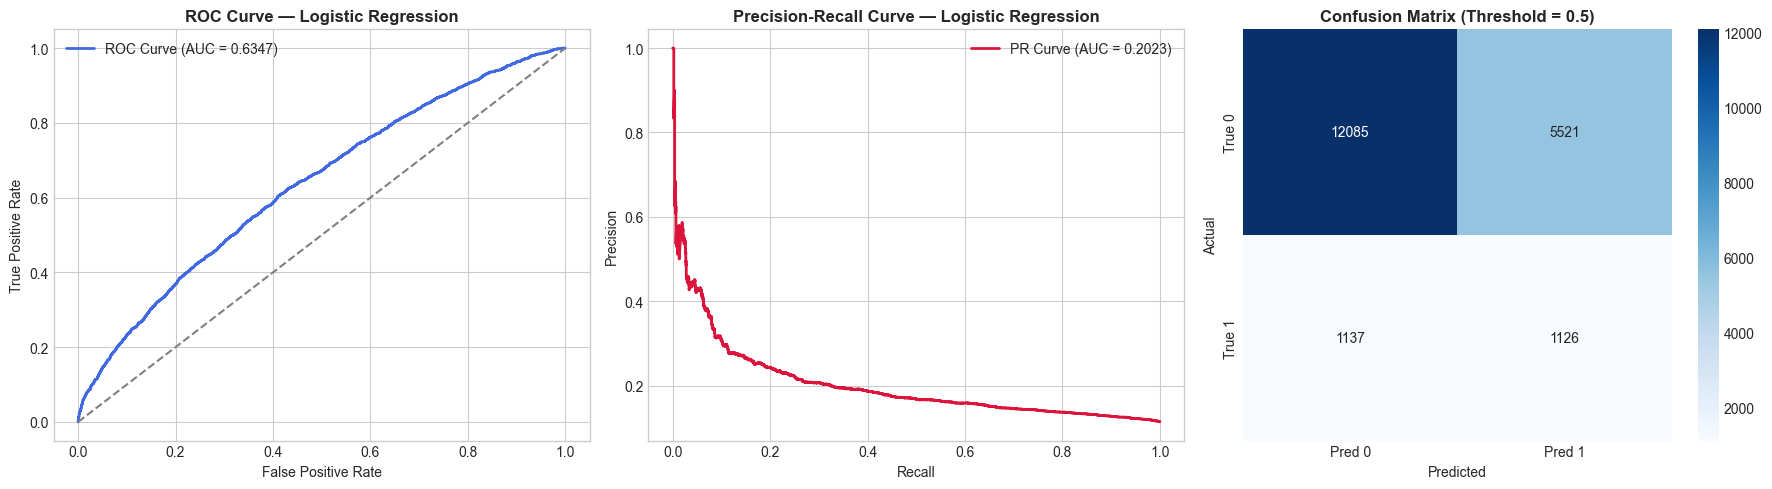

In [8]:
# Step 7 — Diagnostic Curves & Confusion Matrix Visualizations
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
precisions, recalls, _ = precision_recall_curve(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_chosen)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: ROC Curve
axes[0].plot(fpr, tpr, color='royalblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_title('ROC Curve — Logistic Regression', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate'); axes[0].legend()

# Subplot 2: Precision-Recall Curve
axes[1].plot(recalls, precisions, color='crimson', lw=2, label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[1].set_title('Precision-Recall Curve — Logistic Regression', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend()

# Subplot 3: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
axes[2].set_title(f'Confusion Matrix (Threshold = {CHOSEN_THRESHOLD})', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()


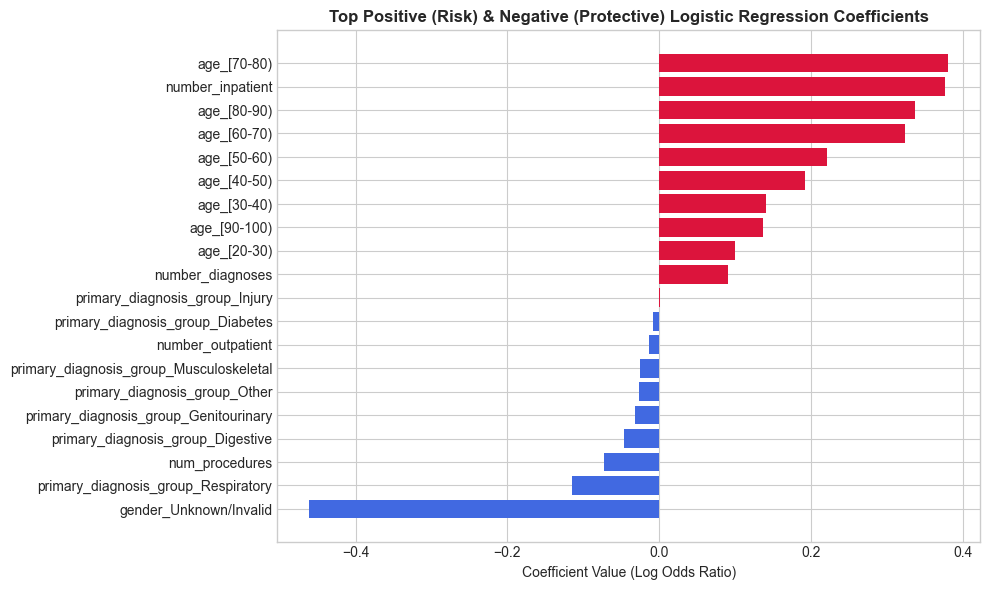

=== TOP RISK FACTOR COEFFICIENTS ===
         Feature  Coefficient  Odds_Ratio
     age_[70-80)     0.380222    1.462610
number_inpatient     0.376518    1.457201
     age_[80-90)     0.337271    1.401119
     age_[60-70)     0.324155    1.382862
     age_[50-60)     0.220314    1.246468
     age_[40-50)     0.192174    1.211881
     age_[30-40)     0.140181    1.150481
    age_[90-100)     0.136379    1.146116
     age_[20-30)     0.099314    1.104413
number_diagnoses     0.090699    1.094940


In [9]:
# Step 8 — Logistic Regression Coefficient & Odds Ratio Explainability
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0],
    'Odds_Ratio': np.exp(lr_model.coef_[0])
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
top_pos = coef_df.head(10)
top_neg = coef_df.tail(10)
plot_df = pd.concat([top_pos, top_neg])

colors = ['crimson' if c > 0 else 'royalblue' for c in plot_df['Coefficient']]
plt.barh(plot_df['Feature'], plot_df['Coefficient'], color=colors)
plt.title('Top Positive (Risk) & Negative (Protective) Logistic Regression Coefficients', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value (Log Odds Ratio)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('=== TOP RISK FACTOR COEFFICIENTS ===')
print(top_pos[['Feature', 'Coefficient', 'Odds_Ratio']].to_string(index=False))

In [10]:
# Step 9 — Save Model & Scaler Artifacts
os.makedirs('results', exist_ok=True)
joblib.dump(lr_model, 'results/lr_model.pkl')
joblib.dump(scaler, 'results/lr_scaler.pkl')

# Save canonical feature columns and threshold for application consistency
import json as _json
artifact_info = {
    'model': 'LogisticRegression',
    'threshold': float(CHOSEN_THRESHOLD),
    'roc_auc': float(roc_auc),
    'pr_auc': float(pr_auc),
    'feature_columns': list(X_train.columns),
    'n_train': len(y_train),
    'n_val': len(y_val),
    'n_test': len(y_test),
    'test_indices': [int(i) for i in test_idx[:10]],
}
with open('results/lr_artifact_info.json', 'w') as f:
    _json.dump(artifact_info, f, indent=2)

print('Successfully saved LR model, scaler, and artifact info to results/')
print(f'Frozen threshold: {CHOSEN_THRESHOLD}')
print(f'Feature count: {X_train.shape[1]}')

Successfully saved LR model, scaler, and artifact info to results/
Frozen threshold: 0.5
Feature count: 29
